In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import mysql.connector
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import os

DB_CONFIG = {
    "host": "localhost",
    "user": "root",
    "password": "YOUR_PASSWORD",
    "database": "lowes_db",
}

def run_query(sql):
    conn = mysql.connector.connect(**DB_CONFIG)
    df = pd.read_sql(sql, conn)
    conn.close()
    return df

In [8]:
df = run_query("SELECT * FROM clean_reviews")

# Create features from what we have
# Latitude as a proxy for "how far north" (mountain vs. coastal)
# one-hot encode the region
df_model = df[["review_count", "overall_rating", "latitude", "longitude", "nc_region"]].copy()

# One-hot encode regions (drop first to avoid multicollinearity)
region_dummies = pd.get_dummies(df_model["nc_region"], prefix="region", drop_first=True)
df_model = pd.concat([df_model, region_dummies], axis=1)
df_model = df_model.drop(columns=["nc_region"])

# we are testing the theory if more urban stores have more ratings than rural one
print(f"Shape: {df_model.shape}")
df_model.head()

Shape: (118, 12)


/var/folders/32/xg3kzz254ng1l1tfj5yxt7k40000gn/T/ipykernel_47676/1327717733.py:19: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(sql, conn)


,review_count,overall_rating,latitude,longitude,region_Coastal,region_Eastern NC,region_Foothills / High Country,region_Mountains / Asheville,region_Other NC,region_Sandhills / Fayetteville,region_Triad,region_Triangle
0,1594,4.2,35.345365,-80.165731,0,0,0,0,0,0,0,0
1,1899,4.2,35.745600,-78.877100,0,0,0,0,0,0,0,1
2,1709,4.1,35.448986,-82.538057,0,0,0,1,0,0,0,0
3,2242,4.2,35.690300,-79.804200,0,0,0,0,0,0,1,0
4,1803,4.0,35.577878,-82.523003,0,0,0,1,0,0,0,0


In [9]:
# Target = review_count, Features = everything else
y = df_model["review_count"]
X = df_model.drop(columns=["review_count"])

# Split the data 75/25 and this is enough for linear regression
X_train, X_test, y_train, y_test = train_test_split(
    
    # 42 is a common random state for reproducibility
    X, y, test_size=0.25, random_state=42
)

model_lr = LinearRegression()
model_lr.fit(X_train, y_train)

y_pred = model_lr.predict(X_test)

In [10]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.0f} reviews")
print(f"R²:   {r2:.3f}")
print(f"\nInterpretation:")
print(f"  The model explains {r2*100:.1f}% of the variance in review counts.")
print(f"  On average, predictions are off by ~{rmse:.0f} reviews.")

# Feature importance
coef_df = pd.DataFrame({
    "feature": X.columns,
    "coefficient": model_lr.coef_
}).sort_values("coefficient", key=abs, ascending=False)

print(f"\nTop features (by absolute coefficient):")
print(coef_df.head(8).to_string(index=False))

RMSE: 682 reviews
R²:   -0.377

Interpretation:
  The model explains -37.7% of the variance in review counts.
  On average, predictions are off by ~682 reviews.

Top features (by absolute coefficient):
                        feature  coefficient
                 overall_rating -2410.639725
   region_Mountains / Asheville  -669.801444
                   region_Triad   354.773959
              region_Eastern NC  -344.629988
region_Foothills / High Country  -254.795535
region_Sandhills / Fayetteville  -225.738804
                       latitude   -45.873329
                region_Triangle   -34.765999


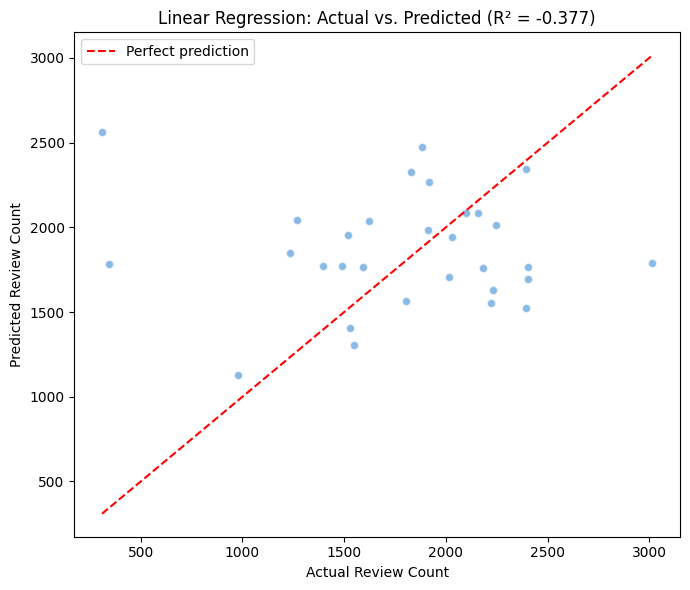

In [11]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(y_test, y_pred, alpha=0.6, color="#3B8BD4", edgecolors="white")
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
        "r--", linewidth=1.5, label="Perfect prediction")
ax.set_xlabel("Actual Review Count")
ax.set_ylabel("Predicted Review Count")
ax.set_title(f"Linear Regression: Actual vs. Predicted (R² = {r2:.3f})")
ax.legend()
plt.tight_layout()
os.makedirs("outputs", exist_ok=True)
plt.savefig("outputs/lr_actual_vs_predicted.png", dpi=150, bbox_inches="tight")
plt.show()

# This is a linear regression model predicting review counts based on geographic region as the strongest predictor.

In [12]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# we are going to group stores into clusters based on customer engagement, this will allow operations teams distribute resources more effectively to high traffic vs low traffic stores
df_clust = run_query("""
    SELECT store_number, city, overall_rating, review_count,
           latitude, longitude, nc_region
    FROM clean_reviews
""")

# This is K-Means it uses distance between points without scaling, that is why we added standardscaler to put everthing on the same scale.
features = ["overall_rating", "review_count", "latitude", "longitude"]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clust[features])

print(f"Clustering {len(df_clust)} stores on {len(features)} features")

Clustering 118 stores on 4 features


/var/folders/32/xg3kzz254ng1l1tfj5yxt7k40000gn/T/ipykernel_47676/1327717733.py:19: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(sql, conn)


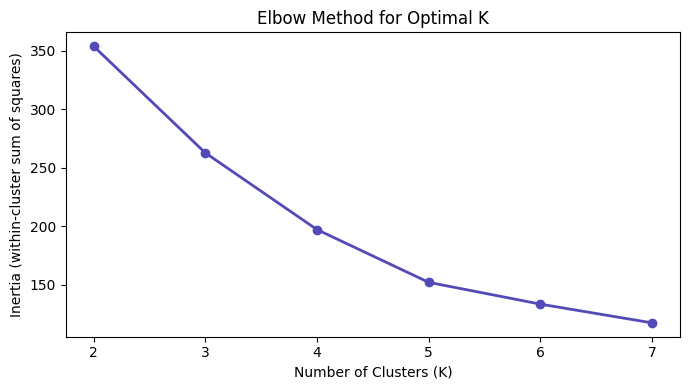

In [13]:
# Determine the optimal number of clusters using the Elbow method
inertias = []
K_range = range(2, 8)

# cluster analysis to determine the optimal number of clusters (K) by plotting the explained variation against the number of clusters.
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(K_range, inertias, marker="o", color="#534AB7", linewidth=2)
ax.set_xlabel("Number of Clusters (K)")
ax.set_ylabel("Inertia (within-cluster sum of squares)")
ax.set_title("Elbow Method for Optimal K")
plt.tight_layout()
plt.savefig("outputs/kmeans_elbow.png", dpi=150, bbox_inches="tight")
plt.show()

In [14]:
from sklearn.metrics import silhouette_score

K = 3  # Based on elbow plot
km = KMeans(n_clusters=K, random_state=42, n_init=10)
df_clust["cluster"] = km.fit_predict(X_scaled)

# Silhouette score: measures how well-separated the clusters are
# Range: -1 (bad) to 1 (perfect). Above 0.3 is generally acceptable.
sil_score = silhouette_score(X_scaled, df_clust["cluster"])
print(f"Silhouette Score: {sil_score:.3f}")

# Cluster profiles
profiles = df_clust.groupby("cluster").agg(
    stores=("store_number", "count"),
    avg_rating=("overall_rating", "mean"),
    avg_reviews=("review_count", "mean"),
    avg_lat=("latitude", "mean"),
    top_region=("nc_region", lambda x: x.mode().iloc[0]),
).round(2)

# Data-driven labels: rank clusters by avg_reviews
labels_map = {}
sorted_clusters = profiles["avg_reviews"].sort_values()
tier_names = ["Low-Traffic Rural", "Mid-Market Suburban", "High-Traffic Urban"]
for tier_name, (cluster_id, _) in zip(tier_names, sorted_clusters.items()):
    labels_map[cluster_id] = tier_name

profiles["label"] = profiles.index.map(labels_map)

print("\nCluster Profiles:")
print(profiles.to_string())
print()
for idx, row in profiles.iterrows():
    print(f"  Cluster {idx} → {row['label']} ({int(row['stores'])} stores, "
          f"avg {row['avg_rating']} rating, ~{int(row['avg_reviews'])} reviews)")


Silhouette Score: 0.277

Cluster Profiles:
         stores  avg_rating  avg_reviews  avg_lat       top_region                label
cluster                                                                                
0            70        4.09      2094.64    35.68         Triangle   High-Traffic Urban
1            45        4.20      1322.42    35.29  Charlotte Metro    Low-Traffic Rural
2             3        4.17      1638.33    35.38       Eastern NC  Mid-Market Suburban

  Cluster 0 → High-Traffic Urban (70 stores, avg 4.09 rating, ~2094 reviews)
  Cluster 1 → Low-Traffic Rural (45 stores, avg 4.2 rating, ~1322 reviews)
  Cluster 2 → Mid-Market Suburban (3 stores, avg 4.17 rating, ~1638 reviews)


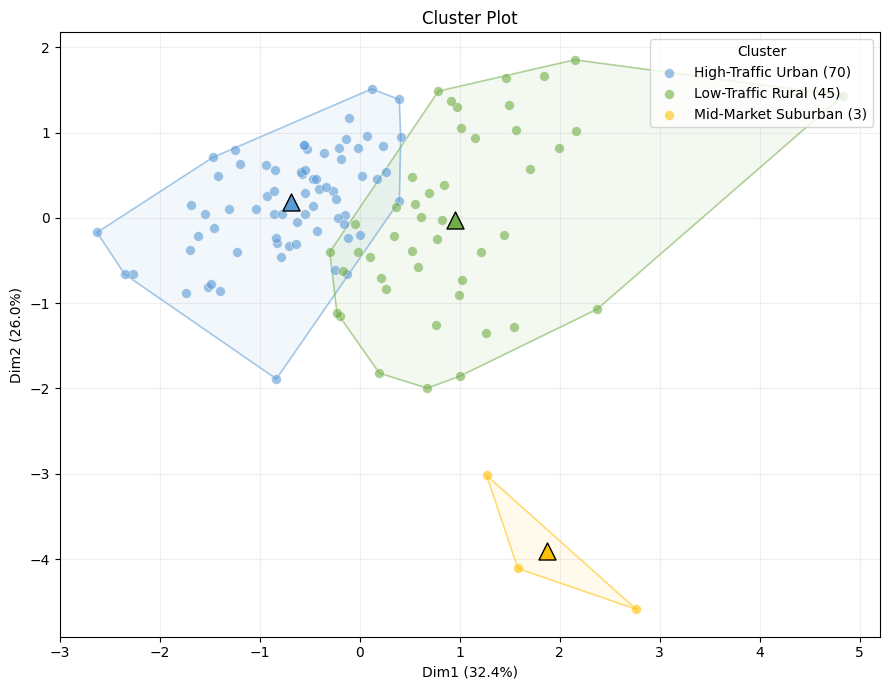


PCA variance explained: Dim1=32.4%, Dim2=26.0%, Total=58.4%


In [ ]:
from sklearn.decomposition import PCA
from scipy.spatial import ConvexHull

# https://365datascience.com/tutorials/python-tutorials/pca-k-means/ 
# PCA reduces our 4 scaled features to 2 dimensions for visualization.
# This is the standard way to visualize K-Means when you have >2 features.
# The axes show how much variance each component explains.
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df_clust["dim1"] = X_pca[:, 0]
df_clust["dim2"] = X_pca[:, 1]

# Transform centroids to PCA space too
centroids_pca = pca.transform(km.cluster_centers_)

var1 = pca.explained_variance_ratio_[0] * 100
var2 = pca.explained_variance_ratio_[1] * 100

# Plot with convex hulls (like R's fviz_cluster)
fig, ax = plt.subplots(figsize=(9, 7))
colors = ["#5B9BD5", "#70AD47", "#FFC000"]
fill_alpha = 0.08

for cluster_id in range(K):
    mask = df_clust["cluster"] == cluster_id
    points = df_clust.loc[mask, ["dim1", "dim2"]].values
    label = labels_map.get(cluster_id, f"Cluster {cluster_id}")

    # Scatter points
    ax.scatter(points[:, 0], points[:, 1],
               c=colors[cluster_id], alpha=0.6, s=50,
               label=f"{label} ({mask.sum()})",
               edgecolors="white", linewidth=0.5, zorder=3)

    # Convex hull (shaded polygon around each cluster)
    if len(points) >= 3:
        hull = ConvexHull(points)
        hull_pts = np.append(hull.vertices, hull.vertices[0])  # close the polygon
        ax.fill(points[hull_pts, 0], points[hull_pts, 1],
                color=colors[cluster_id], alpha=fill_alpha, zorder=1)
        ax.plot(points[hull_pts, 0], points[hull_pts, 1],
                color=colors[cluster_id], linewidth=1.2, alpha=0.5, zorder=2)

    # Centroid as triangle
    ax.scatter(centroids_pca[cluster_id, 0], centroids_pca[cluster_id, 1],
               marker="^", c=colors[cluster_id], s=150,
               edgecolors="black", linewidth=1, zorder=4)

ax.set_xlabel(f"Dim1 ({var1:.1f}%)")
ax.set_ylabel(f"Dim2 ({var2:.1f}%)")
ax.set_title("Cluster Plot")
ax.legend(title="Cluster", loc="upper right")
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig("outputs/kmeans_clusters.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nPCA variance explained: Dim1={var1:.1f}%, Dim2={var2:.1f}%, Total={var1+var2:.1f}%")


/var/folders/32/xg3kzz254ng1l1tfj5yxt7k40000gn/T/ipykernel_47676/1327717733.py:19: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(sql, conn)


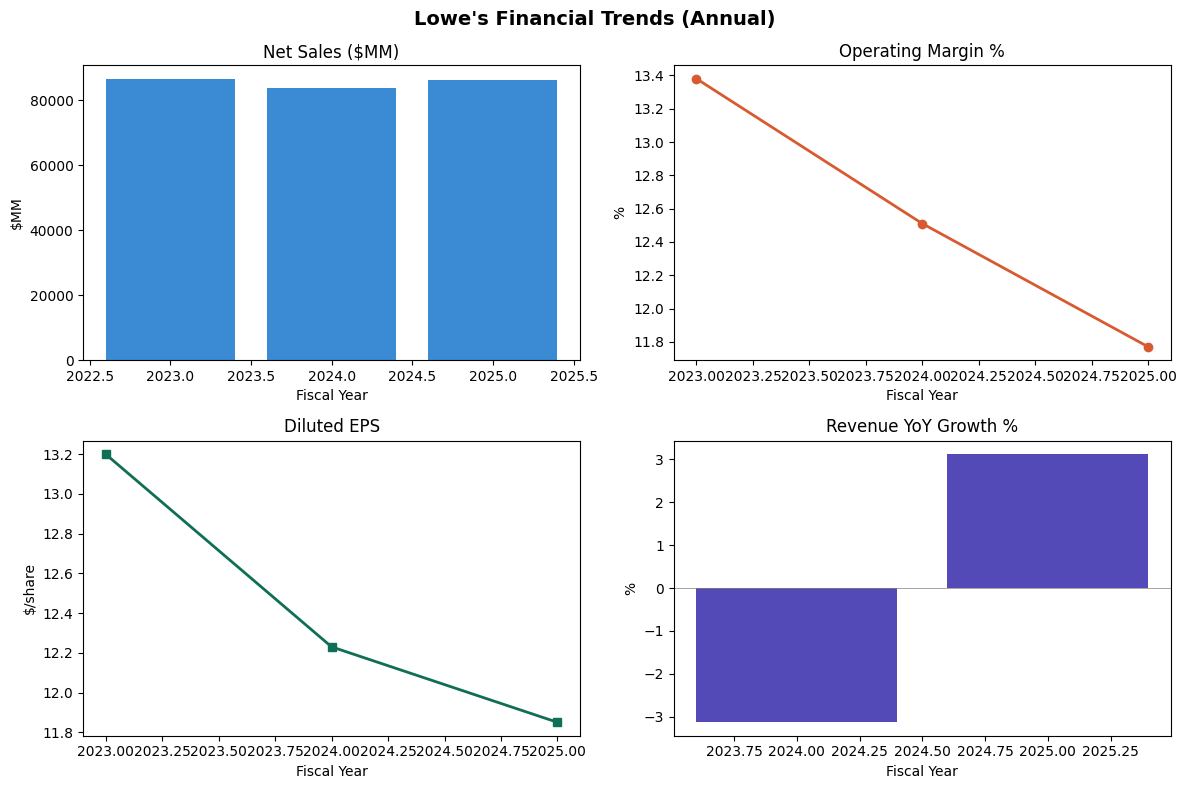

In [16]:
df_fin = run_query("""
    SELECT fiscal_year, net_sales_mm, operating_margin_pct,
           gross_margin_pct, inventory_turnover, diluted_earn_per_share
    FROM clean_financials
    WHERE fiscal_quarter = 'FY'
    ORDER BY fiscal_year
""")

# Year-over-year revenue growth
df_fin["revenue_yoy_pct"] = df_fin["net_sales_mm"].pct_change() * 100

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle("Lowe's Financial Trends (Annual)", fontsize=14, fontweight="bold")

# Revenue
axes[0, 0].bar(df_fin["fiscal_year"], df_fin["net_sales_mm"], color="#3B8BD4")
axes[0, 0].set_title("Net Sales ($MM)")
axes[0, 0].set_ylabel("$MM")

# Operating Margin
axes[0, 1].plot(df_fin["fiscal_year"], df_fin["operating_margin_pct"],
                marker="o", color="#D85A30", linewidth=2)
axes[0, 1].set_title("Operating Margin %")
axes[0, 1].set_ylabel("%")

# EPS
axes[1, 0].plot(df_fin["fiscal_year"], df_fin["diluted_earn_per_share"],
                marker="s", color="#0F6E56", linewidth=2)
axes[1, 0].set_title("Diluted EPS")
axes[1, 0].set_ylabel("$/share")

# Revenue YoY Growth
axes[1, 1].bar(df_fin["fiscal_year"], df_fin["revenue_yoy_pct"], color="#534AB7")
axes[1, 1].set_title("Revenue YoY Growth %")
axes[1, 1].set_ylabel("%")
axes[1, 1].axhline(0, color="gray", linewidth=0.5)

for ax in axes.flat:
    ax.set_xlabel("Fiscal Year")

plt.tight_layout()
plt.savefig("outputs/financial_trends_4panel.png", dpi=150, bbox_inches="tight")
plt.show()

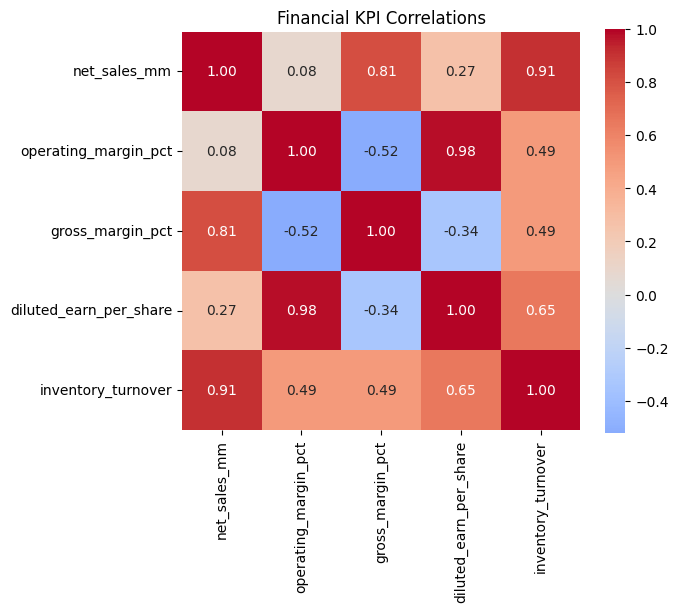

In [17]:
import seaborn as sns

corr_cols = ["net_sales_mm", "operating_margin_pct", "gross_margin_pct",
             "diluted_earn_per_share", "inventory_turnover"]
corr_matrix = df_fin[corr_cols].corr().round(2)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0,
            square=True, ax=ax, fmt=".2f")
ax.set_title("Financial KPI Correlations")
plt.tight_layout()
plt.savefig("outputs/financial_correlation.png", dpi=150, bbox_inches="tight")
plt.show()